# 03. Non-seasonal ARIMA on energy demand

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/03_arima_energy_demand.ipynb)

**Module 3.** You will build an ARIMA($p$, $d$, $q$) model step by step: choose $d$, read the ACF and PACF, search a grid of orders with AIC and BIC, fit by maximum likelihood with `SARIMAX`, check the residuals with the Ljung-Box test, and forecast.

The ARIMA($p$, $d$, $q$) model applies an ARMA($p$, $q$) model to the $d$-times differenced series:

$$
\phi(B)\,(1 - B)^d\, y_t = c + \theta(B)\,\varepsilon_t,
$$

where $B$ is the backshift operator ($B y_t = y_{t-1}$).

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def load_energy():
    """Load the daily energy demand file. Local copy first, GitHub copy on Colab."""
    for base in (Path("../data"), Path("data")):
        path = base / "energy_demand_daily.csv"
        if path.exists():
            break
    else:
        path = RAW + "energy_demand_daily.csv"
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df

In [2]:
from statsmodels.tsa.stattools import adfuller


def adf(series, label, regression="c"):
    """Run the Augmented Dickey-Fuller test and print a plain verdict."""
    stat, pvalue, lags, nobs, crit, _ = adfuller(series.dropna(), regression=regression, autolag="AIC")
    verdict = "reject the unit root (looks stationary)" if pvalue < 0.05 else "cannot reject the unit root (looks non-stationary)"
    print(f"{label:<28} ADF = {stat:7.2f}   p = {pvalue:.4f}   lags = {lags:<3} -> {verdict}")

The series is weekly mean demand, from January 2021 to December 2024. We start in 2021 because the spring 2020 demand shock distorts the earlier years. Notebook 05 treats that break on purpose.

synthetic weekly mean demand (GWh) | 208 weeks | 2021-01-10 to 2024-12-29


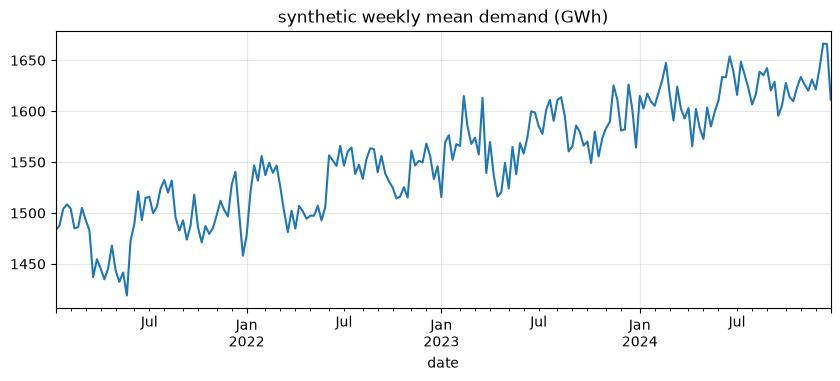

In [3]:
USE_OPSD = False   # Set to True to try the real Open Power System Data series for Germany (needs the internet).

energy = load_energy()
weekly = energy["demand_gwh"].loc["2021-01-04":"2024-12-29"].resample("W-SUN").mean()   # whole Monday-to-Sunday weeks
source = "synthetic weekly mean demand (GWh)"

if USE_OPSD:
    url = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
    try:
        opsd = pd.read_csv(url, parse_dates=["Date"], index_col="Date")
        weekly = opsd["Consumption"].loc["2012-01-02":"2017-12-24"].resample("W-SUN").mean().dropna()
        source = "OPSD Germany weekly mean consumption (GWh per day)"
        print("Citation: Open Power System Data. 2020. Data Package Time series. Version 2020-10-06. "
              "https://doi.org/10.25832/time_series/2020-10-06.")
    except Exception as exc:
        print("Download failed, using the synthetic series instead:", exc)

weekly.index.freq = "W-SUN"
print(source, "|", len(weekly), "weeks |", weekly.index.min().date(), "to", weekly.index.max().date())
weekly.plot(title=source)
plt.show()

## 1. Hold out the last 26 weeks

Never judge a model on the data it was fitted on. Keep the last half year for testing.

In [4]:
H = 26
train, test = weekly.iloc[:-H], weekly.iloc[-H:]
print("train:", len(train), "weeks | test:", len(test), "weeks")

train: 182 weeks | test: 26 weeks


## 2. Choose the order of differencing $d$

In [5]:
adf(train, "level")
adf(train.diff(), "first difference")

level                        ADF =   -1.55   p = 0.5111   lags = 2   -> cannot reject the unit root (looks non-stationary)
first difference             ADF =  -12.40   p = 0.0000   lags = 1   -> reject the unit root (looks stationary)


The level is not stationary on its own, and the first difference is. Use $d = 1$. If the first difference had still failed, you would try $d = 2$, but that is rare in practice.

## 3. Identify $p$ and $q$ from the ACF and PACF of the differenced series

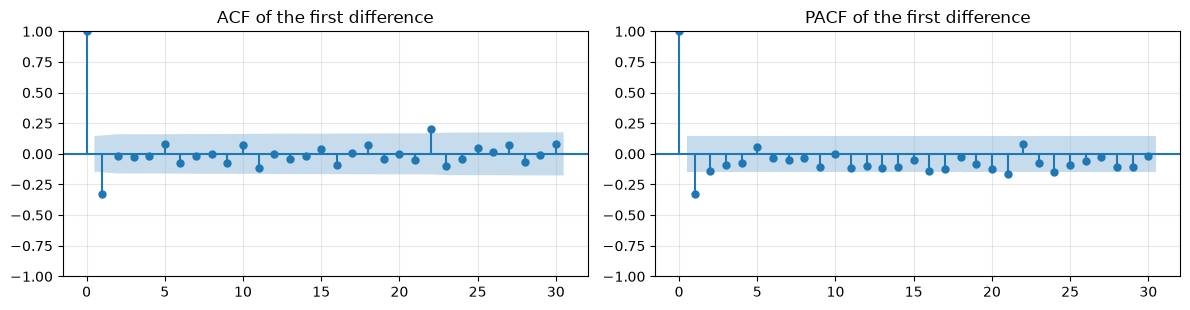

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
plot_acf(train.diff().dropna(), lags=30, ax=axes[0], title="ACF of the first difference")
plot_pacf(train.diff().dropna(), lags=30, ax=axes[1], title="PACF of the first difference", method="ywm")
plt.tight_layout()
plt.show()

Both plots show spikes at the first lags, so a low-order ARMA is a good start. The plots suggest candidates, and the next step compares them with a criterion.

## 4. Model selection with AIC and BIC

$$
\text{AIC} = 2k - 2\ln \hat L, \qquad \text{BIC} = k \ln n - 2\ln \hat L,
$$

where $k$ is the number of parameters, $n$ is the sample size, and $\hat L$ is the maximized likelihood. Lower is better. BIC penalizes extra parameters more, so it prefers smaller models. Report both.

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # start-value and convergence notes for some high-order fits
    for p in range(4):
        for q in range(4):
            res = SARIMAX(train, order=(p, 1, q)).fit(disp=False)
            rows.append({"p": p, "d": 1, "q": q, "AIC": res.aic, "BIC": res.bic})
grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
display(grid.head(6).round(1))
print("Lowest AIC:", tuple(grid.loc[0, ["p", "d", "q"]].astype(int)),
      "| lowest BIC:", tuple(grid.sort_values("BIC").iloc[0][["p", "d", "q"]].astype(int)))

,p,d,q,AIC,BIC
0,2,1,1,1617.7,1630.5
1,0,1,1,1619.0,1625.4
2,1,1,3,1619.5,1635.4
3,3,1,1,1619.5,1635.4
4,2,1,2,1619.5,1635.5
5,1,1,1,1620.6,1630.2


Lowest AIC: (2, 1, 1) | lowest BIC: (0, 1, 1)


## 5. Fit the model

Two models within about 2 AIC points are practically tied. The next cell picks the simpler one. This is the **parsimony rule**, and it protects you from overfitting.

`SARIMAX` is the general model class in `statsmodels`. With no seasonal or exogenous part, it is an ARIMA model.

In [8]:
# Parsimony rule: among models within 2 AIC points of the best, keep the one with the fewest parameters.
close = grid[grid["AIC"] <= grid["AIC"].min() + 2].copy()
close["k"] = close["p"] + close["q"]
choice = close.sort_values(["k", "AIC"]).iloc[0]
best = (int(choice["p"]), 1, int(choice["q"]))
print(f"Candidates within 2 AIC points: {len(close)}. Chosen order: {best}")
model = SARIMAX(train, order=best)
fit = model.fit(disp=False)
print(fit.summary().tables[1])
print(f"\nAIC = {fit.aic:.1f}   BIC = {fit.bic:.1f}   log-likelihood = {fit.llf:.1f}")

Candidates within 2 AIC points: 5. Chosen order: (0, 1, 1)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3942      0.069     -5.702      0.000      -0.530      -0.259
sigma2       438.5776     45.853      9.565      0.000     348.708     528.447

AIC = 1619.0   BIC = 1625.4   log-likelihood = -807.5


## 6. Maximum likelihood estimation

`SARIMAX` chooses the coefficients that make the observed data most probable under the model. This is **maximum likelihood estimation (MLE)**. The next cell shows it directly. It holds all parameters at their estimates, moves one coefficient, and plots the log-likelihood. The peak sits at the estimate.

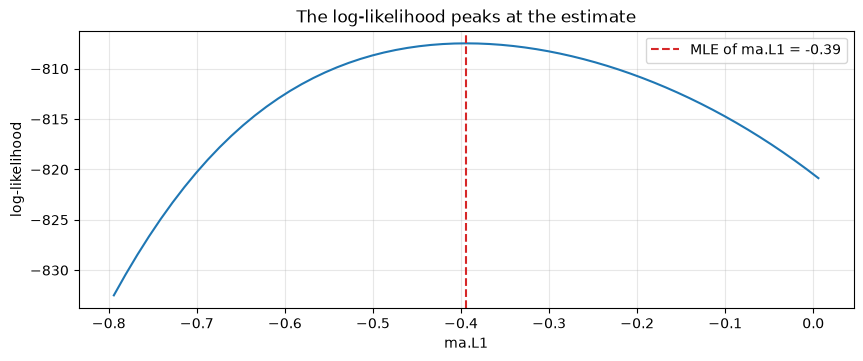

In [9]:
name = fit.param_names[0]
center = fit.params.iloc[0]
grid_vals = np.linspace(max(center - 0.4, -0.98), min(center + 0.4, 0.98), 61)
loglik = []
for v in grid_vals:
    params = fit.params.copy()
    params.iloc[0] = v
    loglik.append(model.loglike(params.values))

plt.plot(grid_vals, loglik)
plt.axvline(center, color="tab:red", ls="--", label=f"MLE of {name} = {center:.2f}")
plt.xlabel(name)
plt.ylabel("log-likelihood")
plt.legend()
plt.title("The log-likelihood peaks at the estimate")
plt.show()

## 7. Residual diagnostics

A good model leaves residuals that look like white noise: no pattern, constant variance, no autocorrelation. The **Ljung-Box test** checks the autocorrelation. Its null hypothesis is "no autocorrelation up to lag $m$". A small p-value means the model missed structure.

,lb_stat,lb_pvalue
10,4.9480,0.8388
26,24.8990,0.4680
52,70.6271,0.0357


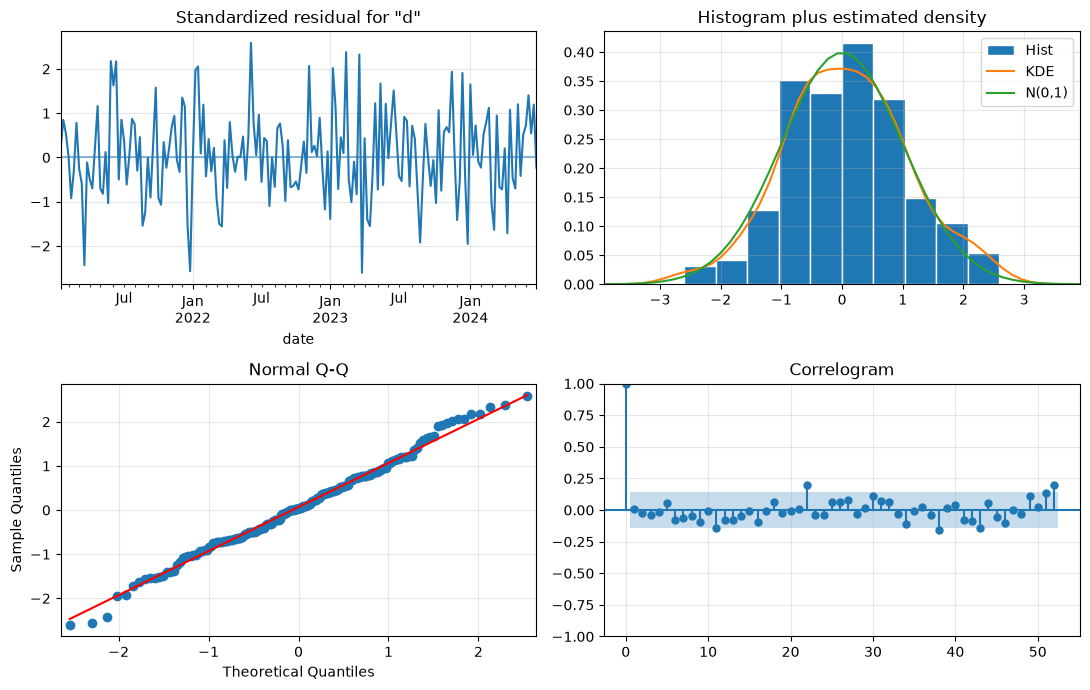

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = fit.resid.iloc[best[1]:]          # drop the first d residuals
lb = acorr_ljungbox(resid, lags=[10, 26, 52], model_df=best[0] + best[2], return_df=True)
display(lb.round(4))
fit.plot_diagnostics(figsize=(11, 7), lags=52)
plt.tight_layout()
plt.show()

**Read the result.** The test passes at lags 10 and 26. At lag 52 the p-value is about 0.04, which is borderline, and the correlogram shows a small spike near lag 52. A year has 52 weeks, so the model leaves a mild **annual pattern** in the residuals. A non-seasonal ARIMA cannot repeat a yearly cycle. The effect is small here, so the forecast below is still close. Notebook 04 adds seasonal terms and external drivers, which is the right fix when the pattern is large.

This is the key habit: **fit, then diagnose, then decide**. A low AIC does not prove the model is adequate, and a borderline test deserves a second look.

## 8. Forecast the held-out weeks

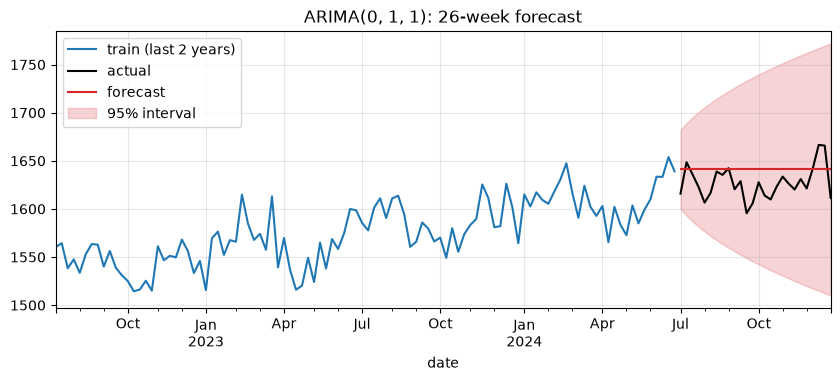

MAE over 26 weeks = 18.5 GWh  (1.1% of the mean level)


In [11]:
fc = fit.get_forecast(steps=H)
mean = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots()
train.iloc[-104:].plot(ax=ax, label="train (last 2 years)")
test.plot(ax=ax, label="actual", color="black")
mean.plot(ax=ax, label="forecast", color="tab:red")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="tab:red", alpha=0.2, label="95% interval")
ax.legend()
ax.set_title(f"ARIMA{best}: {H}-week forecast")
plt.show()

mae = (test - mean).abs().mean()
print(f"MAE over {H} weeks = {mae:.1f} GWh  ({100 * mae / test.mean():.1f}% of the mean level)")

An ARIMA(0,1,1) model gives a **flat** forecast. It has no way to repeat a weekly or yearly pattern. The interval widens with the horizon, which is honest: uncertainty grows when you look further ahead. The error is small here because this half-year has a calm level. A horizon that covers the swing between seasons would show the weakness more.

## Take-home

- Choose $d$ first, then read the ACF and PACF, then compare orders with AIC and BIC.
- Estimate by maximum likelihood. Check the fit with the Ljung-Box test and the residual plots.
- If the residuals still show structure, the model is not done, even when the AIC is the lowest in the grid.

**Next:** notebook 04 adds seasonality and external variables.